A girl plays T-ball .
A woman in riding attire rides a jumping horse .
A brown dog wearing a pink shirt is followed by a brown dog wearing a yellow shirt .


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

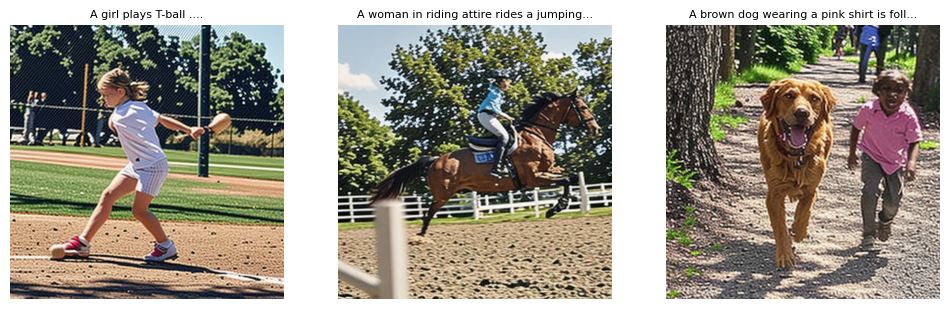

In [1]:
# ---- STAGE 1: LOAD & INSPECT ----
import pandas as pd

# Point to the FILE inside the folder, not the folder itself
captions_path = "/kaggle/input/datasets/adityajn105/flickr8k/captions.txt"
captions_df = pd.read_csv(captions_path)

sample_captions = captions_df["caption"].drop_duplicates().sample(3, random_state=42).tolist()

for c in sample_captions:
    print(c)

# ---- STAGE 2: LOAD PRETRAINED MODEL ----
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

# ---- STAGE 3: GENERATE ----
import matplotlib.pyplot as plt

images = [
    pipe(prompt=c, num_inference_steps=4, guidance_scale=0.0).images[0]
    for c in sample_captions
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (img, cap) in enumerate(zip(images, sample_captions)):
    axes[i].imshow(img)
    axes[i].set_title(cap[:40] + "...", fontsize=8)
    axes[i].axis("off")
plt.show()

# ---- STAGE 4: EVALUATE (by hand using rubric) ----
# No code — fill rubric table manually:
# No | Does Image Match Caption? | What's Missing or Wrong?